# 1. Link

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Load dataset

In [12]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DAP391m/insurance.csv')


print("DataFrame 'df' loaded successfully. First 5 rows:")
display(df.head())

DataFrame 'df' loaded successfully. First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 3. Basic EDA

## Charges distribution

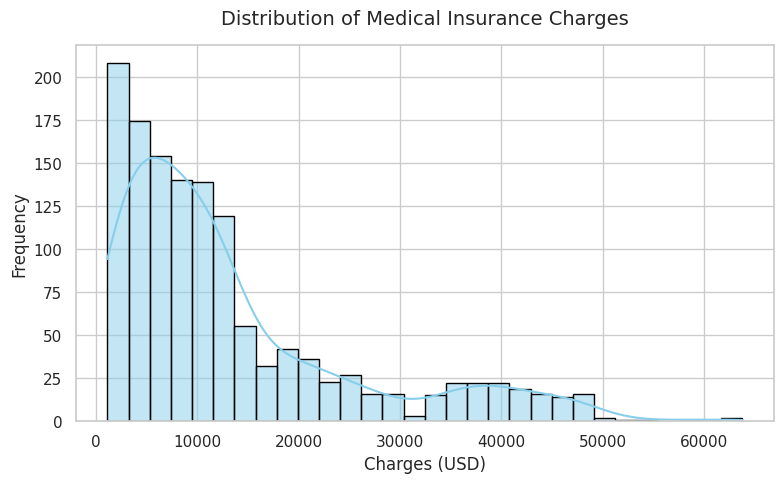

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True, color="skyblue", edgecolor="black")
plt.title('Distribution of Medical Insurance Charges', fontsize=14, pad=15)
plt.xlabel('Charges (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

## Log charges distribution

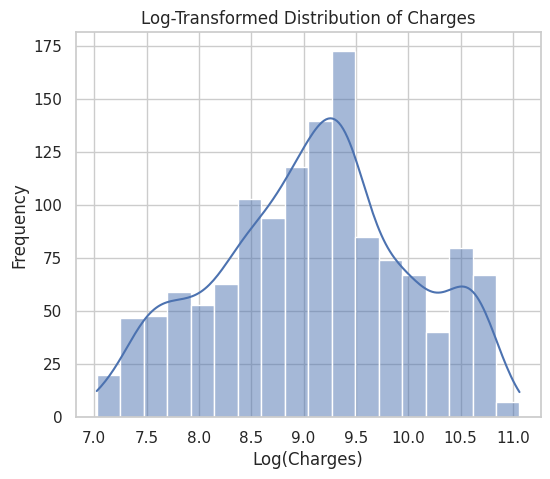

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.histplot(np.log1p(df['charges']), kde=True)
plt.title('Log-Transformed Distribution of Charges')
plt.xlabel('Log(Charges)')
plt.ylabel('Frequency')
plt.show()

## Charges by smoker

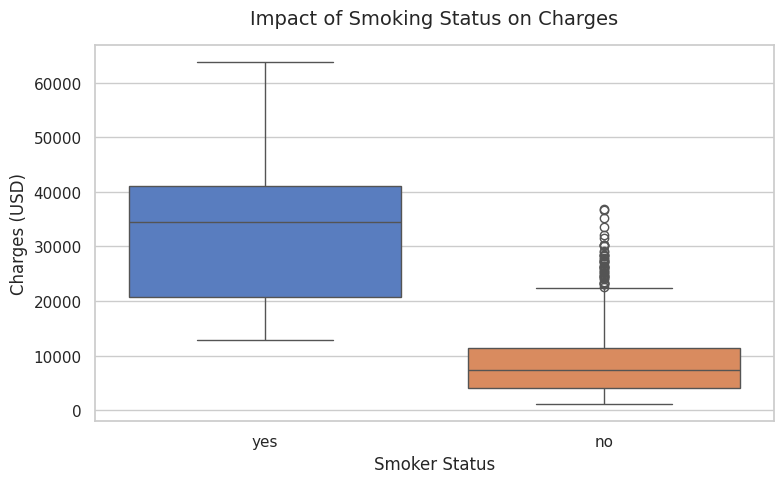

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="smoker", y="charges", data=df, palette="muted", hue="smoker", legend=False)
plt.title('Impact of Smoking Status on Charges', fontsize=14, pad=15)
plt.xlabel('Smoker Status', fontsize=12)
plt.ylabel('Charges (USD)', fontsize=12)
plt.tight_layout()
plt.show()

## Charges by BMI

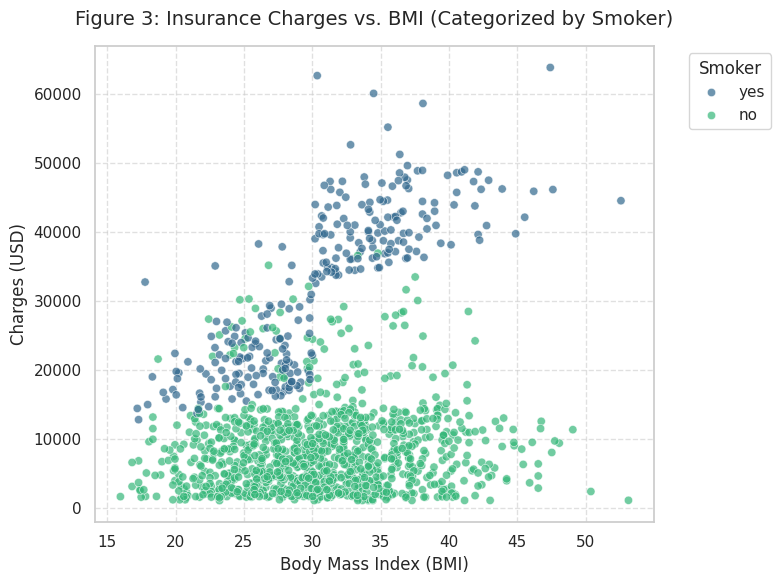

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker",
    data=df,
    alpha=0.7,
    palette="viridis"
)
plt.title("Figure 3: Insurance Charges vs. BMI (Categorized by Smoker)", fontsize=14, pad=15)
plt.xlabel("Body Mass Index (BMI)", fontsize=12)
plt.ylabel("Charges (USD)", fontsize=12)
plt.legend(title='Smoker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Correlation Heatmap

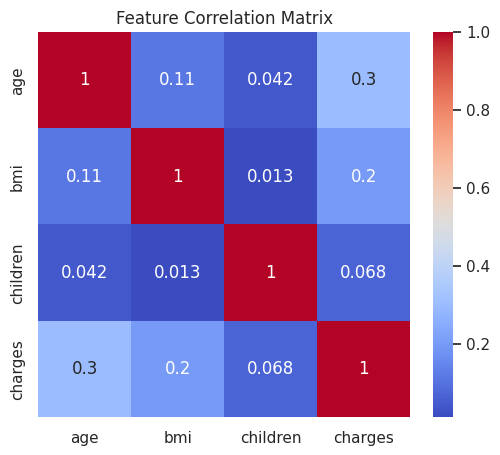

In [17]:
import seaborn as sns

plt.figure(figsize=(6,5))
corr = df.corr(numeric_only=True)


sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

# 4. Feature / Target

In [18]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest



Target (y) head:


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


# 5. Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (1070, 6)
Shape of X_test: (268, 6)


# 6. Preprocessing Pipeline

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

# 7. Evaluation Function

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

# 8. K-FOLD CROSS VALIDATION






In [22]:
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

# 9. Train Models with RAW Target

## Baseline Model (Predict Mean)

In [23]:
from sklearn.dummy import DummyRegressor


baseline_model = DummyRegressor(strategy="mean")


cv = cross_validate(
    baseline_model,
    X,
    y,
    cv=kfold,
    scoring=scoring
)


mae_mean = -cv["test_mae"].mean()
rmse_mean = -cv["test_rmse"].mean()
r2_mean = cv["test_r2"].mean()

## OLS Model

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model_ols = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])


cv_results = cross_validate(
    model_ols,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring
)

mae = -cv_results["test_mae"].mean()
rmse = -cv_results["test_rmse"].mean()
r2 = cv_results["test_r2"].mean()

print(f"OLS CV RMSE: {rmse:.2f}")

OLS CV RMSE: 6123.35


## Ridge Model

In [25]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline

ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipe,
    {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

cv_ridge = cross_validate(best_ridge, X_train, y_train, cv=kfold, scoring=scoring)

mae_ridge = -cv_ridge['test_mae'].mean()
rmse_ridge = -cv_ridge['test_rmse'].mean()
r2_ridge = cv_ridge['test_r2'].mean()

print(f"Best Ridge alpha: {ridge_grid.best_params_}")

Best Ridge alpha: {'model__alpha': 0.1}


## Lasso

In [26]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline

lasso_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

lasso_grid = GridSearchCV(
    lasso_pipe,
    {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
cv_lasso = cross_validate(best_lasso, X_train, y_train, cv=kfold, scoring=scoring)

mae_lasso = -cv_lasso['test_mae'].mean()
rmse_lasso = -cv_lasso['test_rmse'].mean()
r2_lasso = cv_lasso['test_r2'].mean()

print(f"Best Lasso alpha: {lasso_grid.best_params_}")

Best Lasso alpha: {'model__alpha': 10}


## SVR Model

In [27]:
from sklearn.svm import SVR

svr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR())
])

svr_param_grid = {
    'model__kernel': ['rbf'],
    'model__C': [1, 10, 100, 1000],
    'model__epsilon': [0.01, 0.1, 1],
    'model__gamma': ['scale', 0.1, 0.01]
}

svr_grid = GridSearchCV(
    svr_pipe,
    svr_param_grid, cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)
svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_
cv_svr = cross_validate(best_svr, X_train, y_train, cv=kfold, scoring=scoring)

mae_svr = -cv_svr['test_mae'].mean()
rmse_svr = -cv_svr['test_rmse'].mean()
r2_svr = cv_svr['test_r2'].mean()

print(f"Best SVR params: {svr_grid.best_params_}")

Best SVR params: {'model__C': 1000, 'model__epsilon': 1, 'model__gamma': 0.1, 'model__kernel': 'rbf'}


# Feature Importance (OLS coefficients)

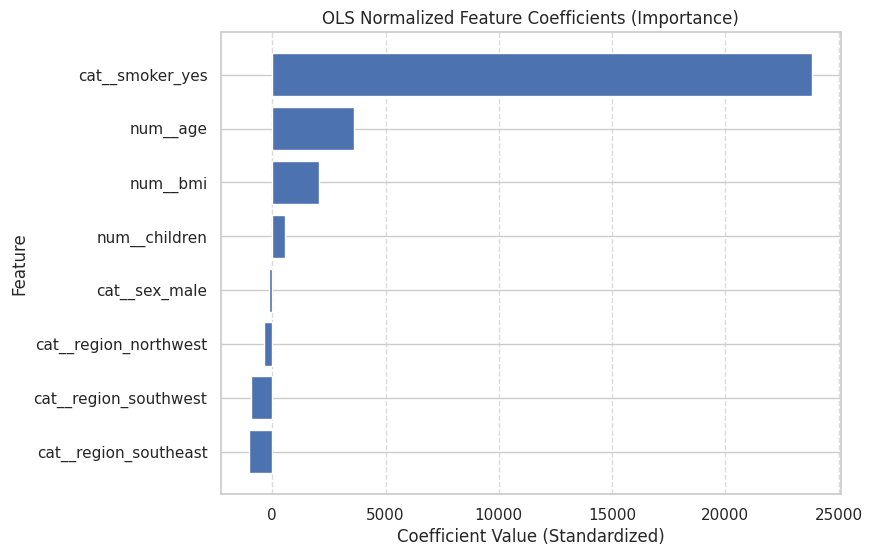

In [28]:
import pandas as pd
import matplotlib.pyplot as plt


model_ols.fit(X, y)


feature_names = model_ols.named_steps["preprocessor"].get_feature_names_out()
coef = model_ols.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values("coefficient")

plt.figure(figsize=(8,6))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.title("OLS Normalized Feature Coefficients (Importance)")
plt.xlabel("Coefficient Value (Standardized)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Table 1 — Result BEFORE log

In [29]:

results_raw = pd.DataFrame({
    "Model": ["Predict Mean", "OLS", "Ridge", "SVR", "Lasso"],
    "MAE": [mae_mean, mae, mae_ridge, mae_svr, mae_lasso],
    "RMSE": [rmse_mean, rmse, rmse_ridge, rmse_svr, rmse_lasso],
    "R2": [r2_mean, r2, r2_ridge, r2_svr, r2_lasso]
})
display(results_raw)

,Model,MAE,RMSE,R2
0,Predict Mean,9090.994473,12085.703777,-0.002462
1,OLS,4234.983570,6123.353823,0.738853
2,Ridge,4236.150665,6123.332084,0.738855
3,SVR,3762.077083,8379.226691,0.511992
4,Lasso,4235.443212,6122.789713,0.738923


# 10. Train Models with LOG Target


## Log Transformation


In [30]:
from sklearn.compose import TransformedTargetRegressor


y_log = np.log1p(df["charges"])
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

## Predict Mean

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def baseline_cv_eval(X_tr, y_tr, kf):
    maes, rmses, r2s = [], [], []
    for train_idx, val_idx in kf.split(X_tr):
        y_fold_train = y_tr.iloc[train_idx]
        y_fold_val = y_tr.iloc[val_idx]

        pred_val_log = np.log1p(y_fold_train).mean()
        y_pred = np.full_like(y_fold_val, np.expm1(pred_val_log))

        maes.append(mean_absolute_error(y_fold_val, y_pred))
        mse = mean_squared_error(y_fold_val, y_pred)
        rmses.append(np.sqrt(mse))
        r2s.append(r2_score(y_fold_val, y_pred))

    return np.mean(maes), np.mean(rmses), np.mean(r2s)

mae_mean_log, rmse_mean_log, r2_mean_log = baseline_cv_eval(X_train, y_train, kfold)

print(f"Baseline (Log Mean) CV on Train Set - MAE: {mae_mean_log:.2f}, RMSE: {rmse_mean_log:.2f}, R2: {r2_mean_log:.2f}")

Baseline (Log Mean) CV on Train Set - MAE: 8301.96, RMSE: 12744.10, R2: -0.13


## OLS



In [32]:
from sklearn.compose import TransformedTargetRegressor

model_ols_log = TransformedTargetRegressor(
    regressor=model_ols,
    func=np.log1p,
    inverse_func=np.expm1
)

cv_ols_log = cross_validate(
    model_ols_log,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring
)

mae_ols_log = -cv_ols_log["test_mae"].mean()
rmse_ols_log = -cv_ols_log["test_rmse"].mean()
r2_ols_log = cv_ols_log["test_r2"].mean()

print(f"OLS Log CV RMSE: {rmse_ols_log:.2f}")

OLS Log CV RMSE: 8427.68


## Ride

In [33]:
ridge_grid_log = GridSearchCV(
    Pipeline([("preprocessor", preprocessor), ("model", Ridge())]),
    {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
ridge_grid_log.fit(X_train, y_train_log)

model_ridge_log_final = TransformedTargetRegressor(
    regressor=ridge_grid_log.best_estimator_,
    func=np.log1p, inverse_func=np.expm1
)

cv_r_log = cross_validate(model_ridge_log_final, X_train, y_train, cv=kfold, scoring=scoring)
mae_ridge_log = -cv_r_log['test_mae'].mean()
rmse_ridge_log = -cv_r_log['test_rmse'].mean()
r2_ridge_log = cv_r_log['test_r2'].mean()

## Lasso

In [34]:
lasso_grid_log = GridSearchCV(
    Pipeline([("preprocessor", preprocessor), ("model", Lasso(max_iter=10000))]),
    {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)
lasso_grid_log.fit(X_train, y_train_log)

model_lasso_log_final = TransformedTargetRegressor(
    regressor=lasso_grid_log.best_estimator_,
    func=np.log1p, inverse_func=np.expm1
)

cv_l_log = cross_validate(model_lasso_log_final, X_train, y_train, cv=kfold, scoring=scoring)
mae_lasso_log = -cv_l_log['test_mae'].mean()
rmse_lasso_log = -cv_l_log['test_rmse'].mean()
r2_lasso_log = cv_l_log['test_r2'].mean()

## SVR

In [35]:
svr_grid_log = GridSearchCV(
    Pipeline([("preprocessor", preprocessor), ("model", SVR())]),
    svr_param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
svr_grid_log.fit(X_train, y_train_log)

model_svr_log_final = TransformedTargetRegressor(
    regressor=svr_grid_log.best_estimator_,
    func=np.log1p, inverse_func=np.expm1
)

cv_s_log = cross_validate(model_svr_log_final, X_train, y_train, cv=kfold, scoring=scoring)
mae_svr_log = -cv_s_log['test_mae'].mean()
rmse_svr_log = -cv_s_log['test_rmse'].mean()
r2_svr_log = cv_s_log['test_r2'].mean()

print(f"Best SVR Log params: {svr_grid_log.best_params_}")
print(f"SVR Log CV RMSE: {rmse_svr_log:.2f}")

Best SVR Log params: {'model__C': 1000, 'model__epsilon': 0.1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
SVR Log CV RMSE: 4882.37


## Table 2 — Result AFTER log



In [36]:
results_log = pd.DataFrame({
    "Model": ["Predict Mean (Log)", "OLS (Log)", "Ridge (Log)", "SVR (Log)", "Lasso (Log)"],
    "MAE (USD)": [mae_mean_log, mae_ols_log, mae_ridge_log, mae_svr_log, mae_lasso_log],
    "RMSE (USD)": [rmse_mean_log, rmse_ols_log, rmse_ridge_log, rmse_svr_log, rmse_lasso_log],
    "R2 Score": [r2_mean_log, r2_ols_log, r2_ridge_log, r2_svr_log, r2_lasso_log]
})

print("Bảng 2: Kết quả sau khi Log Transformation (Tất cả đơn vị là USD)")
display(results_log)

Bảng 2: Kết quả sau khi Log Transformation (Tất cả đơn vị là USD)


,Model,MAE (USD),RMSE (USD),R2 Score
0,Predict Mean (Log),8301.964112,12744.103630,-0.128667
1,OLS (Log),4303.153451,8427.683821,0.504845
2,Ridge (Log),4300.520902,8420.082435,0.505738
3,SVR (Log),2399.486634,4882.366208,0.833421
4,Lasso (Log),4274.813117,8365.632226,0.512137


#11. Residual Plot

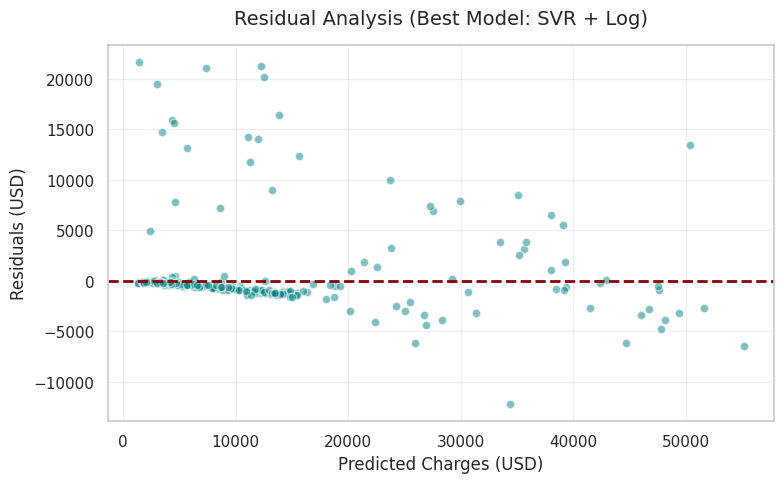

In [37]:
model_svr_log_final.fit(X_train, y_train)
y_pred_test_final = model_svr_log_final.predict(X_test)
residuals_final = y_test - y_pred_test_final

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_final, residuals_final, alpha=0.5, color='teal', edgecolors='white')
plt.axhline(0, color='darkred', linestyle="--", linewidth=2)
plt.xlabel("Predicted Charges (USD)", fontsize=12)
plt.ylabel("Residuals (USD)", fontsize=12)
plt.title("Residual Analysis (Best Model: SVR + Log)", fontsize=14, pad=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()